<a href="https://colab.research.google.com/github/hcoh99/AI_study/blob/main/uci_timesnet_earlystopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
import keras.models
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import to_categorical


def load_file(filepath):
    dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
    return dataframe.values



# load a list of files and return as a 3d numpy array
def load_group(filenames, prefix=''):
    loaded = list()
    for name in filenames:
        data = load_file(prefix + name)
        loaded.append(data)
    # stack group so that features are the 3rd dimension
    loaded = np.dstack(loaded)
    return loaded

# load a dataset group, such as train or test
def load_dataset_group(group, prefix=''):
    filepath = prefix + group + '/Inertial Signals/'
    # load all 9 files as a single array
    filenames = list()
    # total acceleration
    filenames += ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt']
    # body acceleration
    filenames += ['body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt']
    # body gyroscope
    filenames += ['body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
    # load input data
    X = load_group(filenames, filepath)
    # load class output
    y = load_file(prefix + group + '/y_'+group+'.txt')
    return X, y


# load the dataset, returns train and test X and y elements
# load the dataset, returns train and test X and y elements
def load_dataset(prefix=''):
    # load all train
    trainX, trainy = load_dataset_group('train', prefix + '/content/drive/MyDrive/UCI HAR Dataset/')
    # load all test
    testX, testy = load_dataset_group('test', prefix + '/content/drive/MyDrive/UCI HAR Dataset/')

    #zero-offset class values
    trainy = trainy - 1
    testy = testy - 1

    trainy_one_hot = to_categorical(trainy)
    testy_one_hot = to_categorical(testy)
    print(trainX.shape, trainy.shape, trainy_one_hot.shape, testX.shape, testy.shape, testy_one_hot.shape)
    return trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot

In [ ]:
trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot = load_dataset()
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

<ipython-input-5-27e53c02bb4d>:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
<ipython-input-5-27e53c02bb4d>:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
<ipython-input-5-27e53c02bb4d>:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
<ipython-input-5-27e53c02bb4d>:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
<ipython

(7352, 128, 9) (7352, 1) (7352, 6) (2947, 128, 9) (2947, 1) (2947, 6)


In [ ]:
print("X train shape: ", trainX.shape)
print("Y train shape: ", trainy.shape)
print("Y train One hot shape: ", trainy_one_hot.shape)
print("X test shape: ", testX.shape)
print("Y test shape: ", testy.shape)
print("Y test One hot shape: ", testy_one_hot.shape)

X train shape:  (7352, 128, 9)
Y train shape:  (7352, 1)
Y train One hot shape:  (7352, 6)
X test shape:  (2947, 128, 9)
Y test shape:  (2947, 1)
Y test One hot shape:  (2947, 6)


In [ ]:
print("0: Walking:" ,np.where(trainy == 0)[0].size)
print("1: WU:" ,np.where(trainy == 1)[0].size)
print("2: WD:" ,np.where(trainy == 2)[0].size)
print("3: Sitting:" ,np.where(trainy == 3)[0].size)
print("4: Standing:" ,np.where(trainy == 4)[0].size)
print("5: Laying:" ,np.where(trainy == 5)[0].size)

0: Walking: 1226
1: WU: 1073
2: WD: 986
3: Sitting: 1286
4: Standing: 1374
5: Laying: 1407


In [ ]:
unique, counts = np.unique(trainy, return_counts=True)
print ("Train data label statistics::")
print (np.asarray((unique, counts)).T)

unique, counts = np.unique(testy, return_counts=True)
print ("Test data label statistics::")
print (np.asarray((unique, counts)).T)

Train data label statistics::
[[   0 1226]
 [   1 1073]
 [   2  986]
 [   3 1286]
 [   4 1374]
 [   5 1407]]
Test data label statistics::
[[  0 496]
 [  1 471]
 [  2 420]
 [  3 491]
 [  4 532]
 [  5 537]]


In [ ]:
X_train_all = trainX   # at this stage, the data includes both dynamic and static HAR data
y_train_all = trainy

X_test_all = testX
y_test_all = testy

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix
import math

# Device 설정
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

# --- DataEmbedding ---
class DataEmbedding(nn.Module):
    def __init__(self, c_in, d_model, embed_type='fixed', freq='h', dropout=0.1):
        super(DataEmbedding, self).__init__()
        self.value_embedding = nn.Linear(c_in, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, x_mark):
        x = self.value_embedding(x)
        return self.dropout(x)

# --- Inception_Block_V2 (Improved Version) ---
class Inception_Block_V2(nn.Module):
    def __init__(self, in_channels, out_channels, num_kernels=3):
        super(Inception_Block_V2, self).__init__()
        kernel_sizes = [3, 5, 7][:num_kernels]
        self.conv_branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=(1, k), padding=(0, k // 2)),
                nn.BatchNorm2d(out_channels),
                nn.GELU()
            ) for k in kernel_sizes
        ])
        self.fusion = nn.Conv2d(out_channels, out_channels, kernel_size=1)

    def forward(self, x):
        outputs = [branch(x) for branch in self.conv_branches]
        out = sum(outputs) / len(outputs)  # average instead of sum
        return self.fusion(out)

# --- FFT_for_Period ---
def FFT_for_Period(x, k=2):
    xf = torch.fft.rfft(x, dim=1)
    frequency_list = abs(xf).mean(0).mean(-1)
    frequency_list[0] = 0
    _, top_list = torch.topk(frequency_list, k)
    top_list = top_list.detach().cpu().numpy()
    period = x.shape[1] // top_list
    return period, abs(xf).mean(-1)[:, top_list]

# --- TimesBlock (Improved) ---
class TimesBlock(nn.Module):
    def __init__(self, configs):
        super(TimesBlock, self).__init__()
        self.seq_len = configs.seq_len
        self.pred_len = configs.pred_len
        self.k = configs.top_k
        self.dropout = nn.Dropout(configs.dropout)
        self.layernorm = nn.LayerNorm(configs.d_model)
        self.conv = nn.Sequential(
            Inception_Block_V2(configs.d_model, configs.d_ff, num_kernels=configs.num_kernels),
            nn.Dropout(configs.dropout),
            Inception_Block_V2(configs.d_ff, configs.d_model, num_kernels=configs.num_kernels),
            nn.Dropout(configs.dropout)
        )

    def forward(self, x):
        B, T, N = x.size()
        period_list, period_weight = FFT_for_Period(x, self.k)
        res = []
        for i in range(self.k):
            period = period_list[i]
            length = ((self.seq_len + self.pred_len + period - 1) // period) * period
            padding = torch.zeros([B, length - (self.seq_len + self.pred_len), N]).to(x.device)
            out = torch.cat([x, padding], dim=1)
            out = out.reshape(B, length // period, period, N).permute(0, 3, 1, 2).contiguous()
            out = self.conv(out)
            out = out.permute(0, 2, 3, 1).reshape(B, -1, N)
            res.append(out[:, :(self.seq_len + self.pred_len), :])
        res = torch.stack(res, dim=-1)
        period_weight = F.softmax(period_weight, dim=1)
        period_weight = period_weight.unsqueeze(1).unsqueeze(1).repeat(1, T, N, 1)
        res = torch.sum(res * period_weight, -1)
        return self.layernorm(x + self.dropout(res))

# --- TimesNet Model (Improved) ---
class Model(nn.Module):
    def __init__(self, configs):
        super(Model, self).__init__()
        self.configs = configs
        self.task_name = configs.task_name
        self.seq_len = configs.seq_len
        self.label_len = configs.label_len
        self.pred_len = configs.pred_len
        self.model = nn.ModuleList([TimesBlock(configs) for _ in range(configs.e_layers)])
        self.enc_embedding = DataEmbedding(configs.enc_in, configs.d_model, configs.embed, configs.freq, configs.dropout)
        self.layer = configs.e_layers
        self.layer_norm = nn.LayerNorm(configs.d_model)
        if self.task_name == 'classification':
            self.act = F.gelu
            self.dropout = nn.Dropout(configs.dropout)
            self.projection = nn.Sequential(
                nn.LayerNorm(configs.d_model * configs.seq_len),
                nn.Linear(configs.d_model * configs.seq_len, configs.d_model),
                nn.GELU(),
                nn.Dropout(configs.dropout),
                nn.Linear(configs.d_model, configs.num_class)
            )

    def classification(self, x_enc, x_mark_enc):
        enc_out = self.enc_embedding(x_enc, None)
        for i in range(self.layer):
            enc_out = self.layer_norm(self.model[i](enc_out))
        output = self.act(enc_out)
        output = self.dropout(output)
        output = output * x_mark_enc.unsqueeze(-1)
        output = output.reshape(output.shape[0], -1)
        output = self.projection(output)
        return output

    def forward(self, x_enc, x_mark_enc, x_dec=None, x_mark_dec=None, mask=None):
        if self.task_name == 'classification':
            return self.classification(x_enc, x_mark_enc)
        return None

# --- Config 클래스 ---
class Config:
    def __init__(self):
        self.task_name = 'classification'
        self.seq_len = 128
        self.label_len = 128
        self.pred_len = 0
        self.e_layers = 3
        self.enc_in = 9
        self.d_model = 64
        self.embed = 'fixed'
        self.freq = 'h'
        self.dropout = 0.1
        self.d_ff = 256
        self.num_kernels = 3
        self.top_k = 2
        self.num_class = 12
        self.c_out = 1

print("Improved TimesNet model loaded.")


Using device: cuda
Improved TimesNet model loaded.


In [ ]:
# 📌 학습 기록용 리스트 (꼭 위에 있어야 함)
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# ✅ 학습 시작
print("Training start with Early Stopping...")

best_val_acc = 0.0
patience = 10
patience_counter = 0
save_path = "best_model.pth"

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        mask = torch.ones(batch_X.size(0), batch_X.size(1)).to(device)
        outputs = model(batch_X, mask, None, None)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    # ✅ 검증
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for val_X, val_y in test_loader:
            val_X, val_y = val_X.to(device), val_y.to(device)
            mask_val = torch.ones(val_X.size(0), val_X.size(1)).to(device)
            outputs_val = model(val_X, mask_val, None, None)
            loss_val = criterion(outputs_val, val_y)
            running_val_loss += loss_val.item() * val_X.size(0)
            _, predicted_val = torch.max(outputs_val, 1)
            correct_val += (predicted_val == val_y).sum().item()
            total_val += val_y.size(0)

    val_loss = running_val_loss / total_val
    val_acc = 100.0 * correct_val / total_val

    # ✅ 결과 출력
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # ✅ 기록 저장 (시각화를 위한 핵심!)
    train_losses.append(epoch_loss)
    val_losses.append(val_loss)
    train_accuracies.append(epoch_acc)
    val_accuracies.append(val_acc)

    # ✅ Early Stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), save_path)
        print(f"✅ Best model saved! Val Acc: {val_acc:.2f}%")
    else:
        patience_counter += 1
        print(f"⏳ Patience {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("⛔ Early stopping triggered.")
            break

# ✅ 최적 모델 로드
model.load_state_dict(torch.load(save_path))
print("🔁 Best model loaded for final evaluation.")

Training start with Early Stopping...
Epoch 1/100 | Train Loss: 0.2190 | Train Acc: 91.55% | Val Loss: 0.8074 | Val Acc: 80.15%
✅ Best model saved! Val Acc: 80.15%
Epoch 2/100 | Train Loss: 0.1642 | Train Acc: 93.32% | Val Loss: 0.3586 | Val Acc: 88.63%
✅ Best model saved! Val Acc: 88.63%
Epoch 3/100 | Train Loss: 0.1429 | Train Acc: 93.97% | Val Loss: 0.2845 | Val Acc: 92.70%
✅ Best model saved! Val Acc: 92.70%
Epoch 4/100 | Train Loss: 0.1329 | Train Acc: 94.50% | Val Loss: 0.3622 | Val Acc: 92.81%
✅ Best model saved! Val Acc: 92.81%
Epoch 5/100 | Train Loss: 0.1413 | Train Acc: 94.53% | Val Loss: 0.2170 | Val Acc: 92.81%
⏳ Patience 1/10
Epoch 6/100 | Train Loss: 0.1175 | Train Acc: 95.09% | Val Loss: 0.2231 | Val Acc: 92.57%
⏳ Patience 2/10
Epoch 7/100 | Train Loss: 0.1284 | Train Acc: 94.36% | Val Loss: 0.3912 | Val Acc: 91.08%
⏳ Patience 3/10
Epoch 8/100 | Train Loss: 0.1371 | Train Acc: 94.41% | Val Loss: 0.2677 | Val Acc: 92.20%
⏳ Patience 4/10
Epoch 9/100 | Train Loss: 0.1250 |

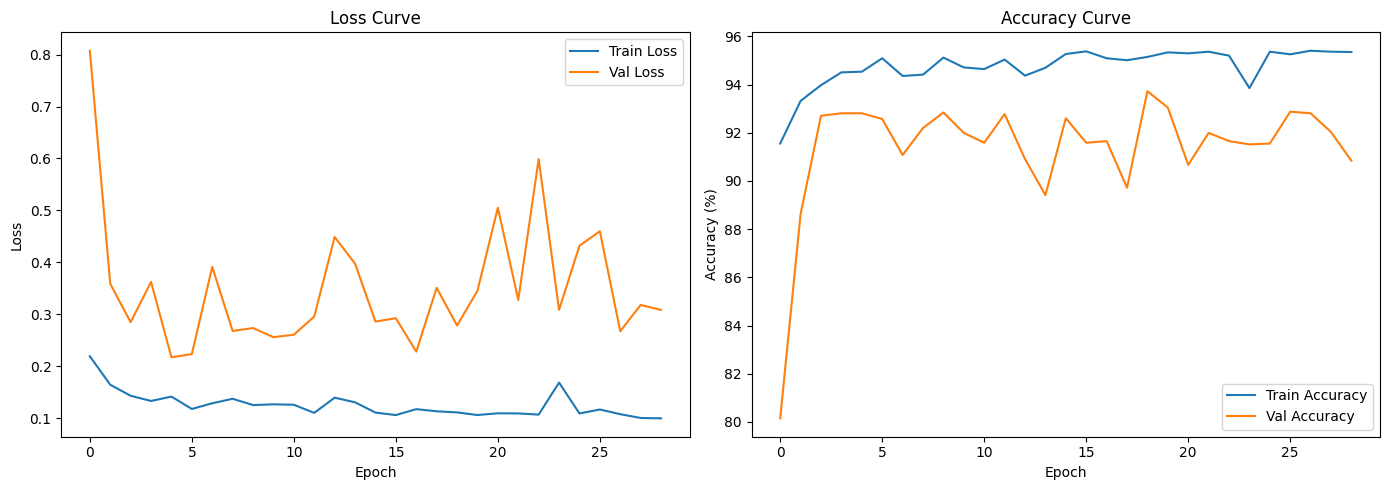


✅ Weighted F1 Score: 0.9366


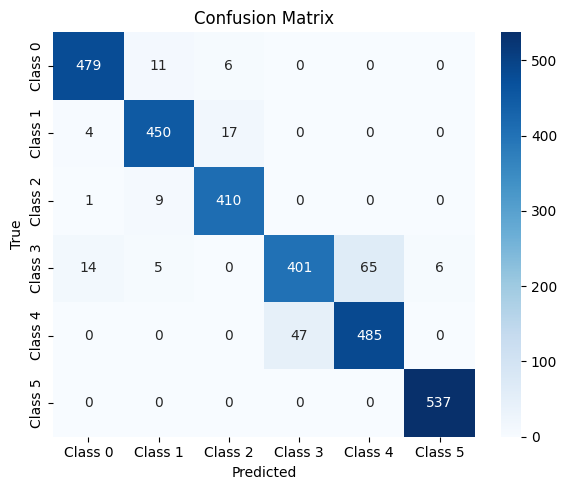


📋 Classification Report:
              precision    recall  f1-score   support

     Class 0       0.96      0.97      0.96       496
     Class 1       0.95      0.96      0.95       471
     Class 2       0.95      0.98      0.96       420
     Class 3       0.90      0.82      0.85       491
     Class 4       0.88      0.91      0.90       532
     Class 5       0.99      1.00      0.99       537

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, classification_report

# ✅ 평가용 리스트 선언 (이미 학습 루프에서 값 저장했다고 가정)
# train_losses, val_losses, train_accuracies, val_accuracies

# ✅ 1. 학습 곡선 시각화
plt.figure(figsize=(14, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Curve')
plt.legend()

plt.tight_layout()
plt.show()

# ✅ 2. 최종 예측 및 성능 측정
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        mask = torch.ones(batch_X.size(0), batch_X.size(1)).to(device)
        outputs = model(batch_X, mask, None, None)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

# ✅ 3. Confusion Matrix & F1 Score
cm = confusion_matrix(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')
print(f"\n✅ Weighted F1 Score: {f1:.4f}")

# 클래스 이름 (6개 클래스 기준, 필요시 수정)
class_names = [f"Class {i}" for i in range(6)]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# ✅ 4. Classification Report
print("\n📋 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))